In [6]:
"""
Created on Tue Aug 19 15:11:47 2025

@author: Admin
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 경로 설정 (업로드된 파일명을 정확하게 사용)
df = pd.read_csv(r"C:\\Users\\Admin\\study01\\20250819\\아파트(매매)_실거래가_20250819144622-ver0.2.csv",encoding="utf-8",sep=";")

if 'contract_date' in df.columns:
    print(df['contract_date'])
else:
    print("컬럼이 존재하지 않습니다.")


# 필요한 컬럼만 선택 및 컬럼명 변경
df = df.rename(columns={
    '시군구': 'sigungu',
    '전용면적(㎡)': 'area_sqm',
    '계약년월': 'contract_ym',
    '계약일': 'contract_day',
    '거래금액(만원)': 'price_krw',
    '층': 'floor',
    '건축년도': 'build_year'
})

# 필요한 컬럼만 선택
df = df[['sigungu', 'area_sqm', 'contract_ym', 'contract_day', 'price_krw', 'floor', 'build_year']]

# 데이터 타입 변환 및 결측치 처리
# 'price_krw' 컬럼에서 쉼표(,) 제거 후 정수형으로 변환
df['price_krw'] = df['price_krw'].str.replace(',', '', regex=False).astype(int)

# 'contract_ym'과 'contract_day'를 합쳐 날짜 컬럼 생성
df['contract_date'] = pd.to_datetime(df['contract_ym'].astype(str) + df['contract_day'].astype(str).str.zfill(2), format='%Y%m%d')

# 결측치 제거 (층, 건축년도 등)
df = df.dropna().reset_index(drop=True)

print("--- 데이터 전처리 완료 ---")
print(df.head())

# 2. 데이터 분할
# 모델 학습을 위해 날짜 정보에서 연도, 월, 요일 등의 새로운 특성을 만들고, 범주형 변수인 'sigungu'를 숫자형으로 변환합니다. 또한, 시계열 데이터이므로 시간 순서대로 학습 및 검증 데이터를 나눕니다.

df['year'] = df['contract_date'].dt.year
df['month'] = df['contract_date'].dt.month
df['weekday'] = df['contract_date'].dt.weekday
df['age_of_building'] = df['year'] - df['build_year']
df.loc[df['age_of_building'] < 0, 'age_of_building'] = 0 # 건축년도 오류값 처리

# 'sigungu'를 레이블 인코딩
le = LabelEncoder()
df['sigungu_encoded'] = le.fit_transform(df['sigungu'])

# 사용할 특성과 타겟 변수 설정
features = ['area_sqm', 'floor', 'age_of_building', 'sigungu_encoded', 'year', 'month', 'weekday']
target = 'price_krw'

# 시간 순서대로 학습/검증 데이터 분할
# 최신 데이터 3개월치를 검증용으로 사용 
df = df.sort_values(by='contract_date')
split_date = df['contract_date'].max() - pd.DateOffset(months=3)

train_df = df[df['contract_date'] < split_date]
valid_df = df[df['contract_date'] >= split_date]

# LightGBM Dataset 생성
dtrain = lgb.Dataset(train_df[features], label=train_df[target])
dvalid = lgb.Dataset(valid_df[features], label=valid_df[target], reference=dtrain)

컬럼이 존재하지 않습니다.
--- 데이터 전처리 완료 ---
         sigungu  area_sqm  contract_ym  contract_day  price_krw  floor  \
0   서울특별시 도봉구 창동     45.90       202508            18      45800     13   
1  서울특별시 구로구 구로동     41.30       202508            18      53000      4   
2  서울특별시 구로구 구로동     44.78       202508            18      42500      2   
3  서울특별시 관악구 봉천동    114.75       202508            18     107000      6   
4  서울특별시 송파구 방이동     56.22       202508            18      57500      9   

   build_year contract_date  
0        1988    2025-08-18  
1        1987    2025-08-18  
2        1988    2025-08-18  
3        2003    2025-08-18  
4        2003    2025-08-18  


In [ ]:

print("\n--- 데이터 분할 완료 ---")
print(f"학습 데이터 크기: {len(train_df)} 건")
print(f"검증 데이터 크기: {len(valid_df)} 건")

# 3. LightGBM 모델 학습 및 예측
# LightGBM 모델을 사용하여 아파트 매매 가격을 예측합니다. 회귀 모델을 사용하며, 검증 데이터의 예측값을 계산해 모델의 성능을 평가합니다.

# LightGBM 모델 파라미터 설정
params = {
    'objective': 'regression_l1', # L1 손실 함수 (MAE) 사용
    'metric': 'mae', # Mean Absolute Error
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}

# 모델 학습
model = lgb.train(
    params,
    dtrain,
    valid_sets=[dvalid],
    callbacks=[lgb.early_stopping(100)]
)

# 검증 데이터에 대한 예측
valid_df['predicted_price'] = model.predict(valid_df[features])

# MSE, MAE, RMSE 계산
mse = mean_squared_error(valid_df[target], valid_df['predicted_price'])
mae = mean_absolute_error(valid_df[target], valid_df['predicted_price'])
rmse = np.sqrt(mse)

print(f"\n--- 모형 적합도 평가 ---")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")


# 잔차(Residuals) 계산
valid_df['residuals'] = valid_df[target] - valid_df['predicted_price']

from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 잔차 분포 시각화 (히스토그램)
plt.figure(figsize=(10, 6))
sns.histplot(valid_df['residuals'], kde=True, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (만원)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 잔차 vs. 예측값 시각화 (산점도)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=valid_df['predicted_price'], y=valid_df['residuals'], alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Price (만원)')
plt.ylabel('Residuals (만원)')
plt.grid(True)
plt.show()

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 수치형 특성만 선택하여 PCA 수행
pca_features = ['area_sqm', 'floor', 'age_of_building', 'year', 'month']
X_pca = df[pca_features]

# 데이터 스케일링 (PCA는 스케일에 민감하므로 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA 모델 생성 및 적합
pca = PCA(n_components=2) # 2개의 주성분으로 차원 축소
X_pca_reduced = pca.fit_transform(X_scaled)

# 주성분 설명 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
print(f"\n--- 주성분 분석 (PCA) ---")
print(f"각 주성분별 설명 분산 비율: {explained_variance_ratio}")
print(f"누적 설명 분산 비율: {np.sum(explained_variance_ratio):.2f}")

# 주성분 시각화 (2D)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_reduced[:, 0], X_pca_reduced[:, 1], c=df[target], cmap='viridis', alpha=0.6)
plt.colorbar(label='Price (만원)')
plt.title('PCA of Features (Colored by Price)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# 예측 결과 시각화
plt.figure(figsize=(12, 6))
sns.regplot(x=valid_df[target], y=valid_df['predicted_price'], scatter_kws={'alpha':0.3})
plt.title('Actual vs. Predicted Price')
plt.xlabel('Actual_Price(만원)')
plt.ylabel('Predicted_Price 가격 (만원)')
plt.grid(True)
plt.show()


컬럼이 존재하지 않습니다.
--- 데이터 전처리 완료 ---
         sigungu  area_sqm  contract_ym  contract_day  price_krw  floor  \
0   서울특별시 도봉구 창동     45.90       202508            18      45800     13   
1  서울특별시 구로구 구로동     41.30       202508            18      53000      4   
2  서울특별시 구로구 구로동     44.78       202508            18      42500      2   
3  서울특별시 관악구 봉천동    114.75       202508            18     107000      6   
4  서울특별시 송파구 방이동     56.22       202508            18      57500      9   

   build_year contract_date  
0        1988    2025-08-18  
1        1987    2025-08-18  
2        1988    2025-08-18  
3        2003    2025-08-18  
4        2003    2025-08-18  

--- 데이터 분할 완료 ---
학습 데이터 크기: 30030 건
검증 데이터 크기: 21406 건
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 15009.1


C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\2096525670.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['predicted_price'] = model.predict(valid_df[features])
C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\2096525670.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['residuals'] = valid_df[target] - valid_df['predicted_price']



--- 모형 적합도 평가 ---
Mean Squared Error (MSE): 864,169,135.95
Mean Absolute Error (MAE): 15,009.10
Root Mean Squared Error (RMSE): 29,396.75


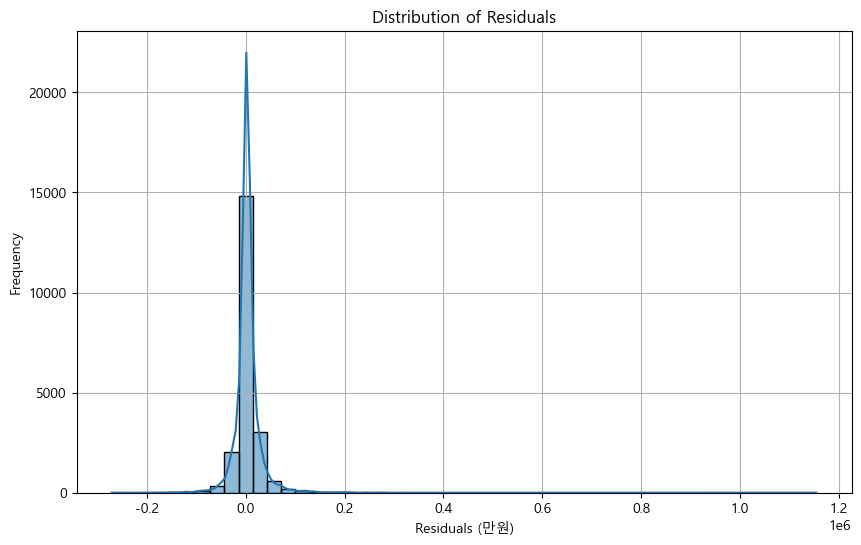

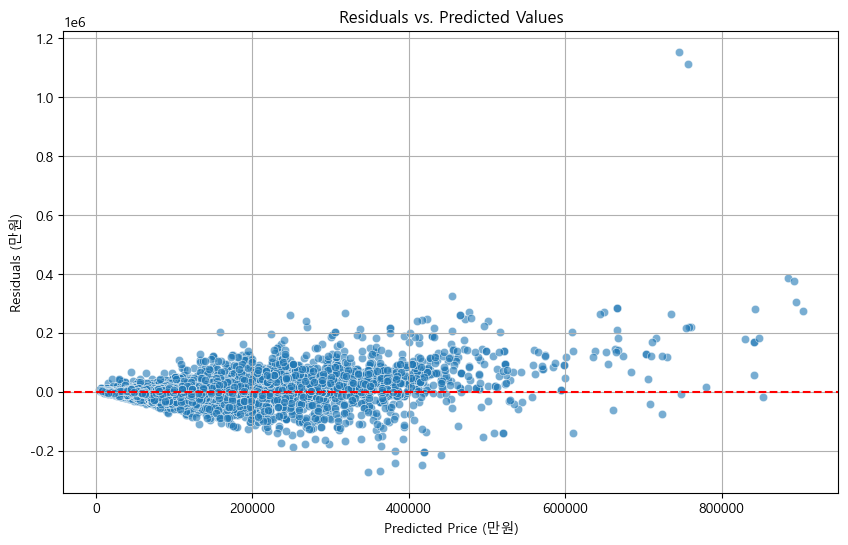


--- 주성분 분석 (PCA) ---
각 주성분별 설명 분산 비율: [0.30595643 0.26702712]
누적 설명 분산 비율: 0.57


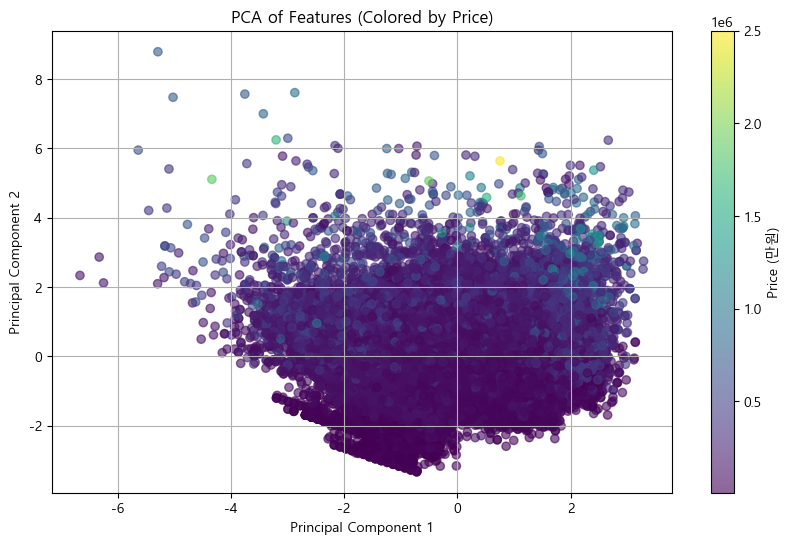

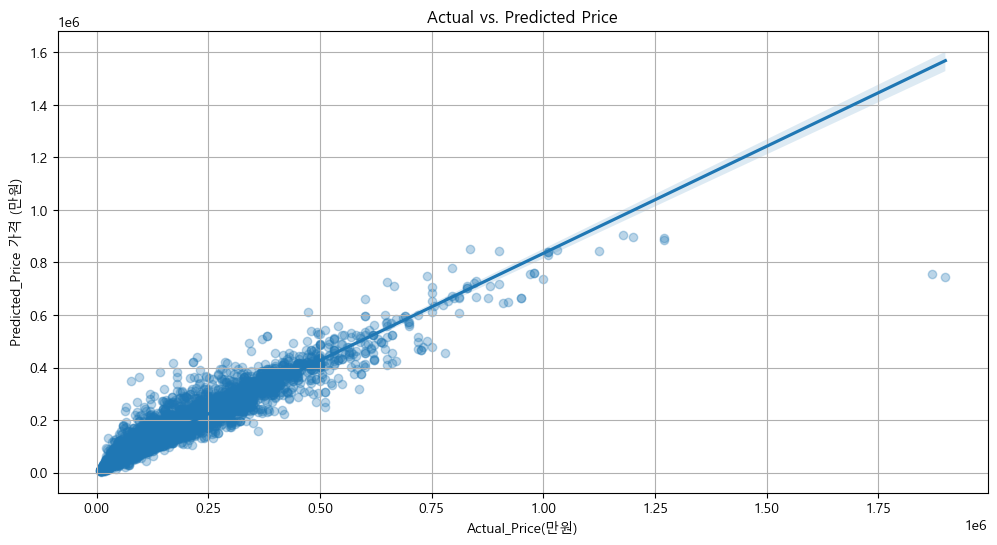


--- 예측 결과 샘플 (일부) ---
             sigungu contract_date  price_krw  predicted_price
3003   서울특별시 구로구 구로동    2025-07-12      48000            52206
14352  서울특별시 강서구 가양동    2025-06-09      95000            91253
9739   서울특별시 광진구 자양동    2025-06-20     139000           131985
16148  서울특별시 강남구 도곡동    2025-06-04      41500            65111
18402  서울특별시 구로구 개봉동    2025-05-29      22400            16343
15792  서울특별시 마포구 대흥동    2025-06-05      19900            29028
12126   서울특별시 강동구 길동    2025-06-14      70000            84415
13586  서울특별시 마포구 도화동    2025-06-12     130000           119767
8169    서울특별시 도봉구 창동    2025-06-23      54000            54643
893    서울특별시 성북구 정릉동    2025-08-01      25808            38340


C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\2096525670.py:193: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['predicted_price'] = result_df['predicted_price'].astype(int)


In [5]:


# 예측 결과 샘플 출력
result_df = valid_df[['sigungu', 'contract_date', 'price_krw', 'predicted_price']]
result_df['predicted_price'] = result_df['predicted_price'].astype(int)
print("\n--- 예측 결과 샘플 (일부) ---")
print(result_df.sample(10))


In [16]:
# result_df.info()
# result_df.columns

result_dict = result_df.to_dict(orient='records')
len(result_dict)

21406

In [15]:
for result in result_dict[:10]:
    print(result)

{'sigungu': '서울특별시 강서구 방화동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 68400, 'predicted_price': 103200}
{'sigungu': '서울특별시 동작구 흑석동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 229700, 'predicted_price': 236935}
{'sigungu': '서울특별시 동작구 노량진동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 132000, 'predicted_price': 123906}
{'sigungu': '서울특별시 금천구 독산동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 108500, 'predicted_price': 108347}
{'sigungu': '서울특별시 구로구 개봉동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 53500, 'predicted_price': 52478}
{'sigungu': '서울특별시 영등포구 대림동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 64800, 'predicted_price': 73163}
{'sigungu': '서울특별시 금천구 시흥동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 52500, 'predicted_price': 55051}
{'sigungu': '서울특별시 구로구 신도림동', 'contract_date': Timestamp('2025-05-18 00:00:00'), 'price_krw': 145500, 'predic